# TC4034
## Análisis de grandes volúmenes de datos

<br>

### **Actividad 4 | Métricas de calidad de resultados**
<br>

## Profesor Titular
Dr. Iván Olmos Pineda

## Profesor Tutor
Mto. Luis D. Mendoza

## Alumno:
Irving Morales Cedeño -                       A01796208

---

In [1]:
import os
import sys
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler,StringIndexer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.clustering import KMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator, MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType, DateType
from pyspark.sql.functions import col, when, expr, rand, row_number, concat_ws, year
from pyspark.sql.window import Window

from sklearn.preprocessing import PowerTransformer, MinMaxScaler, OneHotEncoder

from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, precision_recall_curve


# PARTE 1 - Construcción de la muestra M


---




In [2]:
#Crear sesión de Spark
spark = SparkSession.builder \
    .appName("AnalisisSteam") \
    .config("spark.driver.memory","4g") \
    .getOrCreate()

print("Sesión de Spark creada con éxito")

Sesión de Spark creada con éxito


## Importar base de datos externa

De acuerdo con la descripción provista en Kaggle, el dataset descargado se conforma por:

1. `games.csv` - Una tabla de información sobre juegos (o extras), calificaciones, precio en doláres USD, fecha de lanzamiento, etc. En el archivo de metados se tienen detalles extra no tabulares, como descripciones y etiquetas

2. `users.csv `- Una tabla con la información pública de los perfiles de usuario, con el número de productos comprados y reseñas publicadas.

3. `recommendations.csv` - Una tabla de reseñas de usuarios (se recomienda o no un producto). Esta tabla representa una relación muchos a muchos (many-many) entre una entidad de juego y una entidad de usuario.

---

In [ ]:
df_rec = spark.read.csv('recommendations.csv',header=True,inferSchema=True)
df_rec.printSchema()

root
 |-- app_id: integer (nullable = true)
 |-- helpful: integer (nullable = true)
 |-- funny: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- is_recommended: boolean (nullable = true)
 |-- hours: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- review_id: integer (nullable = true)



In [ ]:
df_rec.count()

41154794

Se eliminan las columnas que no son relevantes para recomendar un juego

In [ ]:
df_rec = df_rec.drop("user_id","review_id")

In [ ]:
df_games = spark.read.csv('games.csv',header=True,inferSchema=True)
df_games.printSchema()

root
 |-- app_id: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- date_release: date (nullable = true)
 |-- win: boolean (nullable = true)
 |-- mac: boolean (nullable = true)
 |-- linux: boolean (nullable = true)
 |-- rating: string (nullable = true)
 |-- positive_ratio: integer (nullable = true)
 |-- user_reviews: integer (nullable = true)
 |-- price_final: double (nullable = true)
 |-- price_original: double (nullable = true)
 |-- discount: double (nullable = true)
 |-- steam_deck: boolean (nullable = true)



In [ ]:
df_games.count()

50872

Se ajusta el dataframe que mantener las columnas que son relevantes para el análisis

In [ ]:
df_games = df_games.select("app_id","title","date_release","rating","price_final")
df_games = df_games.withColumn("Year", year(df_games["date_release"])) #Transformación para tener estadísiticas de la fecha (Año)

In [ ]:
df_games.show()

+------+--------------------+------------+---------------+-----------+----+
|app_id|               title|date_release|         rating|price_final|Year|
+------+--------------------+------------+---------------+-----------+----+
| 13500|Prince of Persia:...|  2008-11-21|  Very Positive|       9.99|2008|
| 22364|BRINK: Agents of ...|  2011-08-03|       Positive|       2.99|2011|
|113020|Monaco: What's Yo...|  2013-04-24|  Very Positive|      14.99|2013|
|226560|  Escape Dead Island|  2014-11-18|          Mixed|      14.99|2014|
|249050|Dungeon of the EN...|  2014-10-27|  Very Positive|      11.99|2014|
|250180|        METAL SLUG 3|  2015-09-14|  Very Positive|       7.99|2015|
|253980|             Enclave|  2013-10-04|Mostly Positive|       4.99|2013|
|271850|Men of War: Assau...|  2014-05-16|          Mixed|       6.99|2014|
|282900|Hyperdimension Ne...|  2015-01-29|  Very Positive|      14.99|2015|
| 19810|The Sum of All Fears|  2008-10-10|Mostly Positive|       9.99|2008|
| 15270|    

Se concatenan ambos dataframes para crear uno final por medio de "app_id"

In [ ]:
df_final = df_rec.join(df_games, on = "app_id", how = "left") # Realizar JOIN
df_final.show(5)

+-------+-------+-----+----------+--------------+-----+--------------+------------+--------------------+-----------+----+
| app_id|helpful|funny|      date|is_recommended|hours|         title|date_release|              rating|price_final|Year|
+-------+-------+-----+----------+--------------+-----+--------------+------------+--------------------+-----------+----+
| 975370|      0|    0|2022-12-12|          true| 36.3|Dwarf Fortress|  2022-12-06|Overwhelmingly Po...|       30.0|2022|
| 304390|      4|    0|2017-02-17|         false| 11.5|    FOR HONOR™|  2017-02-13|               Mixed|       15.0|2017|
|1085660|      2|    0|2019-11-17|          true|336.5|     Destiny 2|  2019-10-01|       Very Positive|        0.0|2019|
| 703080|      0|    0|2022-09-23|          true| 27.4|    Planet Zoo|  2019-11-05|       Very Positive|       45.0|2019|
| 526870|      0|    0|2021-01-10|          true|  7.9|  Satisfactory|  2020-06-08|Overwhelmingly Po...|       30.0|2020|
+-------+-------+-----+-

"app_id" ya no tiene utilidad en este punto, por lo tanto también se elimina

In [ ]:
df_final = df_final.drop("app_id")
df_final.show(5)

+-------+-----+----------+--------------+-----+--------------+------------+--------------------+-----------+----+
|helpful|funny|      date|is_recommended|hours|         title|date_release|              rating|price_final|Year|
+-------+-----+----------+--------------+-----+--------------+------------+--------------------+-----------+----+
|      0|    0|2022-12-12|          true| 36.3|Dwarf Fortress|  2022-12-06|Overwhelmingly Po...|       30.0|2022|
|      4|    0|2017-02-17|         false| 11.5|    FOR HONOR™|  2017-02-13|               Mixed|       15.0|2017|
|      2|    0|2019-11-17|          true|336.5|     Destiny 2|  2019-10-01|       Very Positive|        0.0|2019|
|      0|    0|2022-09-23|          true| 27.4|    Planet Zoo|  2019-11-05|       Very Positive|       45.0|2019|
|      0|    0|2021-01-10|          true|  7.9|  Satisfactory|  2020-06-08|Overwhelmingly Po...|       30.0|2020|
+-------+-----+----------+--------------+-----+--------------+------------+-------------

"df_final" es un dataframe preprocesado conteniendo toda la población "P"

## Implementación de la etapa de particionamiento


De acuerdo al análisis de las entregas anteriores se definió que las columnas más relevantes para el entrenamiento de un modelo son "Date_release", "price_final" y "rating", de acuerdo a ello, a continuación, se definen los estratos.

In [ ]:
# 1. Ingeniería de Características: Clasificar los datos según los umbrales definidos
df_categorizado = df_final.withColumn(
    "categoria_epoca",
    when(col("date_release") < "2018-01-01", "Clasico").otherwise("Nuevo")
).withColumn(
    "categoria_precio",
    when(col("price_final") < 15.0, "Barato").otherwise("Caro")
).withColumn(
    "clasificacion",
    when(col("rating").contains("Negative"), "Negativo")
    .when(col("rating").contains("Positive"), "Positivo")
    .otherwise("Mixto")
)

# 2. Crear la llave de estrato (Segmento)
df_estratos = df_categorizado.withColumn(
    "perfil_juego",
    expr("concat_ws('_', categoria_epoca, clasificacion, categoria_precio)")
)


In [ ]:
# Muestra hasta 100 estratos (o los que haya)
df_estratos.select("perfil_juego").distinct().show(n=100, truncate=False)

+-----------------------+
|perfil_juego           |
+-----------------------+
|Nuevo_Mixto_Barato     |
|Nuevo_Positivo_Barato  |
|Nuevo_Positivo_Caro    |
|Nuevo_Mixto_Caro       |
|Clasico_Positivo_Barato|
|Clasico_Mixto_Barato   |
|Clasico_Positivo_Caro  |
|Clasico_Mixto_Caro     |
|Nuevo_Negativo_Barato  |
|Clasico_Negativo_Caro  |
|Nuevo_Negativo_Caro    |
|Clasico_Negativo_Barato|
+-----------------------+



In [ ]:
total_estratos = df_estratos.select("perfil_juego").distinct().count()
print(f"Total de estratos únicos: {total_estratos}")

Total de estratos únicos: 12


In [ ]:
df_proporciones = df_estratos.groupBy("perfil_juego").count()

total_registros = df_estratos.count()

df_proporciones = df_proporciones.withColumn(
    "proporcion",
    F.col("count") / total_registros
).withColumn(
    "porcentaje",
    F.concat(F.round(F.col("proporcion") * 100, 2), F.lit("%"))
)

df_proporciones.orderBy(F.col("proporcion").desc()).show()

+--------------------+--------+--------------------+----------+
|        perfil_juego|   count|          proporcion|porcentaje|
+--------------------+--------+--------------------+----------+
|Clasico_Positivo_...|10809875|  0.2626638101991228|    26.27%|
| Nuevo_Positivo_Caro|10708069|  0.2601900765193965|    26.02%|
|Clasico_Positivo_...| 9493526| 0.23067849641040603|    23.07%|
|Nuevo_Positivo_Ba...| 6895543|  0.1675513914612232|    16.76%|
|Clasico_Mixto_Barato|  918286| 0.02231297768128787|     2.23%|
|    Nuevo_Mixto_Caro|  901004| 0.02189305090434908|     2.19%|
|  Nuevo_Mixto_Barato|  841708|0.020452246705450646|     2.05%|
|  Clasico_Mixto_Caro|  368852| 0.00896255245500682|      0.9%|
|Nuevo_Negativo_Ba...|  115166|0.002798361716984...|     0.28%|
|Clasico_Negativo_...|   74341|0.001806375218401...|     0.18%|
| Nuevo_Negativo_Caro|   19758|  4.8008987725707E-4|     0.05%|
|Clasico_Negativo_...|    8666|2.105708511139674...|     0.02%|
+--------------------+--------+---------

Se tiene una población de 41,154,794 por lo que se considerará el tamaño de muestra de acuerdo con la fórmula Cochran para poblaciones infinitas. Para este caso se tiene:

* Z = 2.576 (Nivel de confianza 99%)
* p = 0.5 (Para obtener una muestra significativa se toma 50%, más considerando que el objetivo es crear un sistema de recomendación)
* e = 0.01

$$n = \frac{(2.576)^2 \cdot 0.5 \cdot 0.5}{(0.01)^2}$$$$n = \frac{6.635776 \cdot 0.25}{0.0001}$$$$n = \frac{1.658944}{0.0001} = \mathbf{16,590}$$

Entonces el tamaño de la muestra sería de 16,590. Dicha población se distribuirá de acuerdo con los porcentajes que corresponden a cada estrato. Sin embargo, considerando que se tienen algunos estratos muy poco representados, se aumentará arbitrariamente para asumir que todas las categorías deben tener como mínimo 100 elementos, aunque esto afecte la proporción original de los datos, dado que la idea es entrenar un algoritmo de ML y si se tienen estratos poco representados pueden surgir recomendaciones erradas.

In [ ]:
TOTAL_MUESTRA_OBJETIVO = 16590
PISO_MINIMO = 100

total_poblacion = df_estratos.count()

df_cuotas = df_estratos.groupBy("perfil_juego").count() \
    .withColumn(
        "cuota_proporcional",
        F.round((F.col("count") / total_poblacion) * TOTAL_MUESTRA_OBJETIVO).cast("int")
    ) \
    .withColumn(
        "cuota_estrato",
        F.greatest(F.col("cuota_proporcional"), F.lit(PISO_MINIMO))
    ) \
    .select("perfil_juego", "cuota_estrato")

df_con_cuotas = df_estratos.join(df_cuotas, "perfil_juego")

window_spec = Window.partitionBy("perfil_juego").orderBy(F.rand())

df_muestra = df_con_cuotas \
    .withColumn("row_num", F.row_number().over(window_spec)) \
    .filter(F.col("row_num") <= F.col("cuota_estrato")) \
    .drop("row_num", "cuota_estrato")

# Verificar los resultados
df_muestra.groupBy("perfil_juego").count().show()
print(f"Total de la muestra: {df_muestra.count()}")

+--------------------+-----+
|        perfil_juego|count|
+--------------------+-----+
|Clasico_Negativo_...|  100|
|  Nuevo_Mixto_Barato|  339|
|Nuevo_Negativo_Ba...|  100|
| Nuevo_Negativo_Caro|  100|
|Nuevo_Positivo_Ba...| 2780|
|Clasico_Negativo_...|  100|
|    Nuevo_Mixto_Caro|  363|
| Nuevo_Positivo_Caro| 4317|
|Clasico_Positivo_...| 4358|
|Clasico_Mixto_Barato|  370|
|  Clasico_Mixto_Caro|  149|
|Clasico_Positivo_...| 3827|
+--------------------+-----+

Total de la muestra: 16903


"df_muestra" es la muestra M obtenida por la fórmula de Cochran"

In [ ]:
M_df_o = df_muestra.drop('helpful','funny','date', 'title','date_release','categoria_epoca','rating','categoria_precio')
M_df_o.show()

"M_df_o" es el dataframe de la muestra M, quitando información que no es relevante para la etapa de entrenamiento.

In [ ]:
M_df_o.write.mode("overwrite").parquet("m.parquet")

Se guarda la muestra M para su uso posterior

Las siguientes celdas son para un preprocesamiento de la muestra M, antes de crear los conjuntos en entrenamiento y prueba.

In [3]:
M_df = spark.read.parquet("m.parquet")
M_df.show()

+--------------------+--------------+-----+-----------+----+-------------+
|        perfil_juego|is_recommended|hours|price_final|Year|clasificacion|
+--------------------+--------------+-----+-----------+----+-------------+
|Clasico_Positivo_...|          true|  6.7|       10.0|2009|     Positivo|
|Clasico_Positivo_...|          true|  7.8|       7.49|2017|     Positivo|
|Clasico_Positivo_...|          true|270.7|       9.99|2012|     Positivo|
|Clasico_Positivo_...|          true| 65.4|       10.0|2010|     Positivo|
|Clasico_Positivo_...|          true|  5.6|       9.99|2012|     Positivo|
|Clasico_Positivo_...|         false| 32.4|      14.99|2016|     Positivo|
|Clasico_Positivo_...|          true|  5.2|       10.0|2013|     Positivo|
|Clasico_Positivo_...|          true|  1.3|       2.59|2016|     Positivo|
|Clasico_Positivo_...|          true|109.8|        0.0|2017|     Positivo|
|Clasico_Positivo_...|          true| 11.0|      14.99|2017|     Positivo|
|Clasico_Positivo_...|   

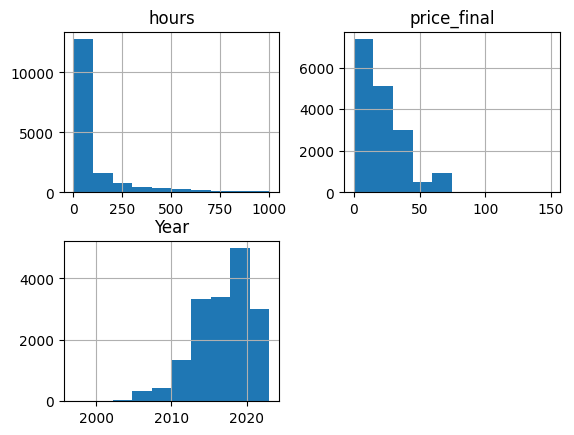

In [4]:
M_pd = M_df.toPandas()
M_pd.hist()
plt.show()

Se observa que las 3 variables están sesgadas por lo que se procede con una transformaciópn Yeo-Johnson/Box-Cox para centrarlas

/usr/local/lib/python3.12/dist-packages/scipy/stats/_morestats.py:1186: UserWarning: The optimal lambda is 161.93671648356764, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in float64.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)


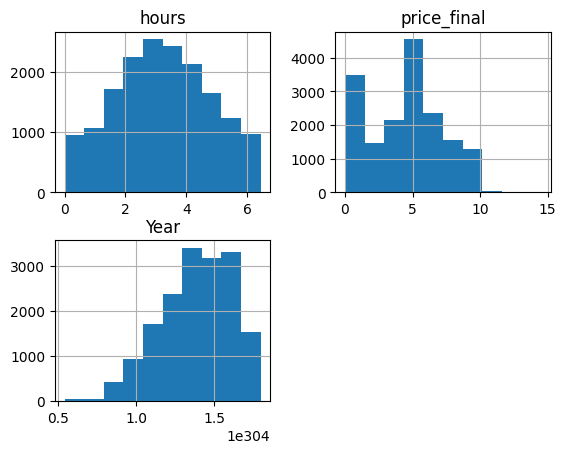

In [5]:
transformer = PowerTransformer(method='yeo-johnson', standardize=False)
transf = transformer.fit_transform(M_pd[['hours','price_final']])
transf_df1 = pd.DataFrame(transf, columns=transformer.get_feature_names_out())

transformer = PowerTransformer(method='box-cox', standardize=False)
transf = transformer.fit_transform(M_pd[['Year']])
transf_df2 = pd.DataFrame(transf, columns=transformer.get_feature_names_out())

transf_df = pd.concat([transf_df1, transf_df2], axis=1)
transf_df.hist()
plt.show()

Como las 3 variables tienen diferentes escalas se procede a unificarlas con MinMax scaler

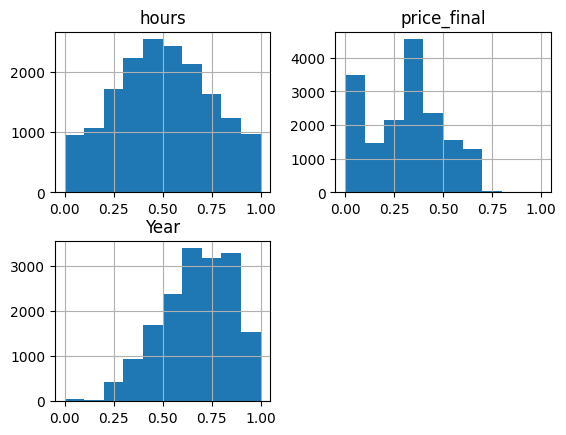

In [6]:
scaler = MinMaxScaler()
minmax = scaler.fit_transform(transf_df)
minmax_df = pd.DataFrame(minmax, columns=scaler.get_feature_names_out())
minmax_df.hist()
plt.show()

Habiendo terminando el análisis de las variables numéricas se procede a crear un nuevo dataframe

In [7]:
M_temp_pd = pd.concat([minmax_df, M_pd[['clasificacion','is_recommended','perfil_juego']]], axis=1)
M_temp_pd

,hours,price_final,Year,clasificacion,is_recommended,perfil_juego
0,0.310232,0.265664,0.320571,Positivo,True,Clasico_Positivo_Barato
1,0.330081,0.224421,0.655534,Positivo,True,Clasico_Positivo_Barato
2,0.821865,0.265512,0.432140,Positivo,True,Clasico_Positivo_Barato
3,0.623990,0.265664,0.356079,Positivo,True,Clasico_Positivo_Barato
4,0.287251,0.265512,0.432140,Positivo,True,Clasico_Positivo_Barato
...,...,...,...,...,...,...
16898,0.128147,0.476323,0.606702,Mixto,False,Clasico_Mixto_Caro
16899,0.168572,0.476323,0.560040,Mixto,True,Clasico_Mixto_Caro
16900,0.226458,0.332761,0.655534,Mixto,True,Clasico_Mixto_Caro
16901,0.367105,0.387508,0.560040,Mixto,True,Clasico_Mixto_Caro


In [8]:
M_temp_df = spark.createDataFrame(M_temp_pd)
M_temp_df = M_temp_df.withColumn("is_recommended", col("is_recommended").cast("integer"))

Se modifica el tipo de data de "is_recommend" a integer para que se pueda usar en el modelo de entrenamiento

In [9]:
M_temp_df.printSchema()

root
 |-- hours: double (nullable = true)
 |-- price_final: double (nullable = true)
 |-- Year: double (nullable = true)
 |-- clasificacion: string (nullable = true)
 |-- is_recommended: integer (nullable = true)
 |-- perfil_juego: string (nullable = true)



Se procede a codificar la variable "clasificacion" para que se pueda usar en el modelo de entrenamiento

In [10]:
clasificacionEncoder = StringIndexer(inputCol='clasificacion',outputCol='rating')
M_temp_df = clasificacionEncoder.fit(M_temp_df).transform(M_temp_df)
M_temp_df.show()

+-------------------+-------------------+-------------------+-------------+--------------+--------------------+------+
|              hours|        price_final|               Year|clasificacion|is_recommended|        perfil_juego|rating|
+-------------------+-------------------+-------------------+-------------+--------------+--------------------+------+
|0.31023209922847317|0.26566411431629733| 0.3205713024764751|     Positivo|             1|Clasico_Positivo_...|   0.0|
|0.33008095172930213|0.22442080573733264|  0.655533723484915|     Positivo|             1|Clasico_Positivo_...|   0.0|
|  0.821865395367196| 0.2655122789521011|0.43213965971598106|     Positivo|             1|Clasico_Positivo_...|   0.0|
| 0.6239900343932654|0.26566411431629733|0.35607921323190356|     Positivo|             1|Clasico_Positivo_...|   0.0|
|0.28725108231551527| 0.2655122789521011|0.43213965971598106|     Positivo|             1|Clasico_Positivo_...|   0.0|
|  0.525411785428739| 0.3326408782258213|  0.606

Se crea un vector de features con todas las variables para un procesado posterior más rápido

In [11]:
assembler = VectorAssembler(inputCols=['hours','price_final','Year','rating'],outputCol='features')
M_temp_df = assembler.transform(M_temp_df)
M_df = M_temp_df.select(['features','is_recommended','perfil_juego'])
M_df.show()

+--------------------+--------------+--------------------+
|            features|is_recommended|        perfil_juego|
+--------------------+--------------+--------------------+
|[0.31023209922847...|             1|Clasico_Positivo_...|
|[0.33008095172930...|             1|Clasico_Positivo_...|
|[0.82186539536719...|             1|Clasico_Positivo_...|
|[0.62399003439326...|             1|Clasico_Positivo_...|
|[0.28725108231551...|             1|Clasico_Positivo_...|
|[0.52541178542873...|             0|Clasico_Positivo_...|
|[0.27790987707624...|             1|Clasico_Positivo_...|
|[0.12814742461868...|             1|Clasico_Positivo_...|
|[0.69655511401313...|             1|Clasico_Positivo_...|
|[0.37597643427099...|             1|Clasico_Positivo_...|
|[0.47567437624547...|             0|Clasico_Positivo_...|
|[0.97126028150763...|             1|Clasico_Positivo_...|
|[0.67645883559426...|             1|Clasico_Positivo_...|
|[0.37597643427099...|             1|Clasico_Positivo_..

In [12]:
M_df.groupBy('is_recommended').count().show()

+--------------+-----+
|is_recommended|count|
+--------------+-----+
|             1|14334|
|             0| 2569|
+--------------+-----+



# PARTE 2 - Construcción Train – Test

---

Como anteriormente ya se tenian bien identificados los estratos y con ello el comportamiento de la población en general, se usará el método de "Stratified Random Sampling". Es decir, a cada estrato se le extraerá de forma aleatoria un 80% de datos para entrenamiento y un 20% para pruebas, con esto se asegura que cada estrato está debidamente representado. Se muestra el número de registros de cada subgrupo para hacer la validación final

In [13]:
train_df_1,test_df_1 = M_df.filter(col('perfil_juego') == 'Clasico_Negativo_Barato').randomSplit([0.8,0.2])
train_df_1.count()
test_df_1.count()

17

In [14]:
train_df_2,test_df_2 = M_df.filter(col('perfil_juego') == 'Nuevo_Mixto_Barato').randomSplit([0.8,0.2])
train_df_2.count()
test_df_2.count()

70

In [15]:
train_df_3,test_df_3 = M_df.filter(col('perfil_juego') == 'Nuevo_Negativo_Barato').randomSplit([0.8,0.2])
train_df_3.count()
test_df_3.count()

28

In [16]:
train_df_4,test_df_4 = M_df.filter(col('perfil_juego') == 'Nuevo_Negativo_Caro').randomSplit([0.8,0.2])
train_df_4.count()
test_df_4.count()

21

In [17]:
train_df_5,test_df_5 = M_df.filter(col('perfil_juego') == 'Nuevo_Positivo_Barato').randomSplit([0.8,0.2])
train_df_5.count()
test_df_5.count()

561

In [18]:
train_df_6,test_df_6 = M_df.filter(col('perfil_juego') == 'Clasico_Negativo_Caro').randomSplit([0.8,0.2])
train_df_6.count()
test_df_6.count()

23

In [19]:
train_df_7,test_df_7 = M_df.filter(col('perfil_juego') == 'Nuevo_Mixto_Caro').randomSplit([0.8,0.2])
train_df_7.count()
test_df_7.count()

66

In [20]:
train_df_8,test_df_8 = M_df.filter(col('perfil_juego') == 'Nuevo_Positivo_Caro').randomSplit([0.8,0.2])
train_df_8.count()
test_df_8.count()

802

In [21]:
train_df_9,test_df_9 = M_df.filter(col('perfil_juego') == 'Clasico_Positivo_Barato').randomSplit([0.8,0.2])
train_df_9.count()
test_df_9.count()

868

In [22]:
train_df_10,test_df_10 = M_df.filter(col('perfil_juego') == 'Clasico_Mixto_Barato').randomSplit([0.8,0.2])
train_df_10.count()
test_df_10.count()

69

In [23]:
train_df_11,test_df_11 = M_df.filter(col('perfil_juego') == 'Clasico_Mixto_Caro').randomSplit([0.8,0.2])
train_df_11.count()
test_df_11.count()

40

In [24]:
train_df_12,test_df_12 = M_df.filter(col('perfil_juego') == 'Clasico_Positivo_Caro').randomSplit([0.8,0.2])
train_df_12.count()
test_df_1.count()

17

Se procede a unificar los dataframes en uno solo de training y otro de pruebas

In [25]:
train_df = train_df_1.union(train_df_2).union(train_df_3).union(train_df_4).union(train_df_5).union(train_df_6).union(train_df_7).union(train_df_8).union(train_df_9).union(train_df_10).union(train_df_11).union(train_df_12)
train_df.count()

13532

In [26]:
test_df = test_df_1.union(test_df_2).union(test_df_3).union(test_df_4).union(test_df_5).union(test_df_6).union(test_df_7).union(test_df_8).union(test_df_9).union(test_df_10).union(test_df_11).union(test_df_12)
test_df.count()

3371

Se confirma que los conjuntos de train y test, cubren por completo la muestra M, sumando un total de 16,903

# PARTE 3 -  Selección de métricas para medir calidad de resultados
---

Como se trata de un problema de recomendación con solo 2 clases: "Si se recomienda" o "No es recomendado" y tomando como base la información del libro y el video, las métricas a monitorear para el modelo Supervisado son:

1) Accuracy
2) F1-score - Ambas clases son relevantes, es importante que el modelo prediga lo mejor posible.
3) Matriz de confusión, para reforzar el punto anterior y verificar que el modelo no está prediciendo solo la clase mayoritaría.
4) La curva ROC/AUC, para evaluar el desempeño en general del modelo.
5) La curva PR, para verificar que haya un balance adecuado de las predicciones entre cada clase.

Para el caso del modelo No Supervisado y dado que son solo 2 clases no hay mucho margen de acción, por lo cual la idea es centrase en que tan bien diferenciados están los dos grupos:

1) Coeficiente de inercia. Mientras mas bajo sea el valor los puntos están mas cerca de sus centroides y por lo tanto los clusters estarían mejor definidos.
2) Coeficiente de silueta. Similar al anterior pero en este caso se busca que sea cercano a 1, para que el punto esté bien agrupado y lejos de otros clusters.

# PARTE 4 -  Entrenamiento de Modelos de Aprendizaje
---

# Supervisado: Regresión Logística

Se inicializa el modelo definiendo cual es la variables a predecir "is_recommended" y aqui es donde se usa la columna de "features" previamente creada

In [27]:
lr = LogisticRegression(featuresCol='features',labelCol='is_recommended')
lr_model = lr.fit(train_df)

In [28]:
tr_metrics_lr = lr_model.summary
print("LR Training Metrics\n")
print(f'Accuracy: {tr_metrics_lr.accuracy:.4f}')
print(f'F1-score: {tr_metrics_lr.weightedFMeasure():.4f}')

LR Training Metrics

Accuracy: 0.8582
F1-score: 0.8161


Con el modelo entrenado, se calculan las predicciones para el conjunto "test"

In [29]:
pred_test_lr = lr_model.transform(test_df)

Se instancia el objeto de métricas y se obtienen para el conjunto test.

In [30]:
te_metrics_lr = MulticlassMetrics(pred_test_lr.select(pred_test_lr["prediction"].cast(FloatType()),
    pred_test_lr["is_recommended"].cast(FloatType())).rdd)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [31]:
print('LR Test Metrics:\n')
print(f'Accuracy: {te_metrics_lr.accuracy:.4f}')
print(f'F1-score: {te_metrics_lr.weightedFMeasure():.4f}\n')
print('Confusion Matrix')
pred_test_lr.crosstab("is_recommended", "prediction").show()
#print(te_metrics.confusionMatrix().toArray())

LR Test Metrics:

Accuracy: 0.8582
F1-score: 0.8181

Confusion Matrix
+-------------------------+---+----+
|is_recommended_prediction|0.0| 1.0|
+-------------------------+---+----+
|                        0| 89| 447|
|                        1| 31|2804|
+-------------------------+---+----+



In [32]:
def grafica_roc (predicciones):

  evaluador_roc = BinaryClassificationEvaluator(
      labelCol="is_recommended",
      rawPredictionCol="probability",
      metricName="areaUnderROC"
  )

  auc_valor = evaluador_roc.evaluate(predicciones)
  print(f"Valor AUC: {auc_valor:.4f}\n")

  datos_grafico = predicciones.select(
      "is_recommended",
      vector_to_array("probability")[1].alias("prob_positiva")
  ).toPandas()

  fpr, tpr, umbrales = roc_curve(datos_grafico['is_recommended'], datos_grafico['prob_positiva'])

  plt.figure(figsize=(8, 6))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_valor:.4f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')

  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('Falsos Positivos (FP)')
  plt.ylabel('Verdaderos Positivos (VP)')
  plt.title('Curva ROC - Regresión Logística')
  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)

  plt.show()
  return None

Valor AUC: 0.7030



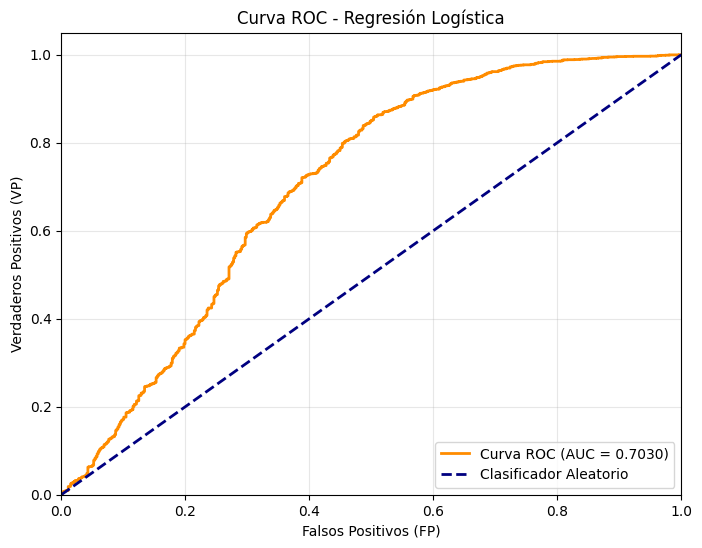

In [33]:
grafica_roc(pred_test_lr)

In [34]:
def grafica_pr (predicciones):

  evaluador_binario = BinaryClassificationEvaluator(
    labelCol="is_recommended",
    rawPredictionCol="probability" # Se usa la columna de probabilidades generada por el modelo
  )

  auc_pr = evaluador_binario.setMetricName("areaUnderPR").evaluate(predicciones)
  print(f"El valor de PR-AUC es: {auc_pr:.4f}")

  datos_grafico_pr = predicciones.select(
      "is_recommended",
      vector_to_array("probability")[1].alias("prob_positiva")
  ).toPandas()

  precision, recall, umbrales = precision_recall_curve(
      datos_grafico_pr['is_recommended'],
      datos_grafico_pr['prob_positiva']
  )

  linea_base = datos_grafico_pr['is_recommended'].mean()
  plt.figure(figsize=(8, 6))
  plt.plot(recall, precision, color='purple', lw=2, label=f'PR-AUC = {auc_pr:.4f})')
  plt.plot([0, 1], [linea_base, linea_base], color='navy', lw=2, linestyle='--',
          label=f'Línea Base Aleatoria (Prop. Positiva = {linea_base:.4f})')

  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('Recall')
  plt.ylabel('Precisión')
  plt.title('Curva Precision-Recall')
  plt.legend(loc="upper right")
  plt.grid(alpha=0.3)

  plt.show()
  return None

El valor de PR-AUC es: 0.8988


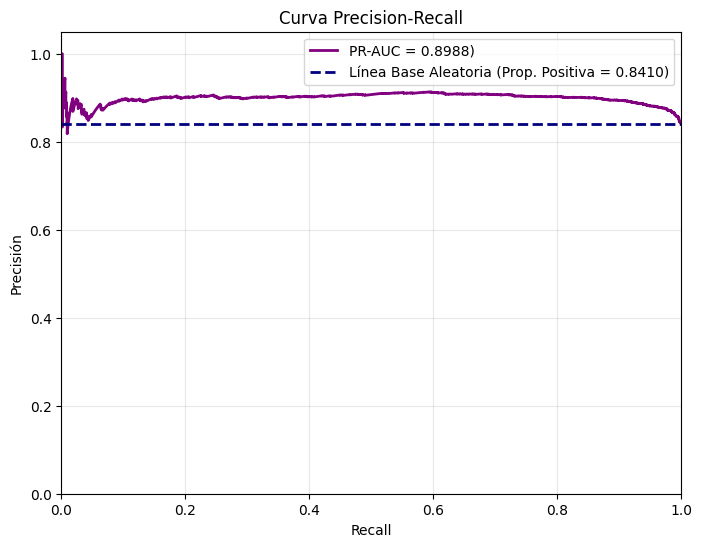

In [35]:
grafica_pr(pred_test_lr)

En general accuracy y F1-score están arriba de 80% por lo que el desempeño del modelo es "aceptable". Sin embargo, al analizar la matriz de confusión y la curva PR se observa que el modelo casi siempre está prediciendo hacia la clase positiva, por lo que se procede a una técnica de pesos en las clases para lograr un mejor balance

In [36]:
# Se calculan las frecuencias y los pesos de cada clase
total_registros = train_df.count()
conteo_positivos = train_df.filter(train_df["is_recommended"] == 1.0).count()
conteo_negativos = total_registros - conteo_positivos

peso_clase_0 = total_registros / (2 * conteo_negativos)
peso_clase_1 = total_registros / (2 * conteo_positivos)

print(f"Peso asignado a la clase minoritaria (0): {peso_clase_0:.4f}")
print(f"Peso asignado a la clase mayoritaria (1): {peso_clase_1:.4f}")

# Se agregan los pesos como columna al dataframe
train_df_w = train_df.withColumn(
    "peso_clase",
    when(train_df["is_recommended"] == 1.0, peso_clase_1).otherwise(peso_clase_0)
)

# Se entrena usando el parámetro "weightCol"
rf = RandomForestClassifier(
    labelCol="is_recommended",
    featuresCol="features",
    weightCol="peso_clase", # ¡Este es el parámetro clave!
    numTrees=100,           # Número de árboles en el ensamble
    maxDepth=5              # Profundidad máxima para evitar sobreajuste
)

rf_model = rf.fit(train_df_w)

pred_test_rf = rf_model.transform(test_df)

Peso asignado a la clase minoritaria (0): 3.3281
Peso asignado a la clase mayoritaria (1): 0.5884


In [37]:
tr_metrics_rf = rf_model.summary
print("RF Training Metrics\n")
print(f'Accuracy: {tr_metrics_rf.accuracy:.4f}')
print(f'F1-score: {tr_metrics_rf.weightedFMeasure():.4f}')

RF Training Metrics

Accuracy: 0.6812
F1-score: 0.6731


In [38]:
te_metrics_rf = MulticlassClassificationEvaluator(labelCol="is_recommended", predictionCol="prediction")

In [39]:
print('RF Test Metrics:\n')
print(f'Accuracy: {te_metrics_rf.setMetricName('accuracy').evaluate(pred_test_rf):.4f}')
print(f'F1-score: {te_metrics_rf.setMetricName('f1').evaluate(pred_test_rf):.4f}\n')
print('Matriz de confusion')
pred_test_rf.crosstab("is_recommended", "prediction").show()


RF Test Metrics:

Accuracy: 0.7912
F1-score: 0.8026

Matriz de confusion
+-------------------------+---+----+
|is_recommended_prediction|0.0| 1.0|
+-------------------------+---+----+
|                        0|273| 263|
|                        1|441|2394|
+-------------------------+---+----+



Valor AUC: 0.7394



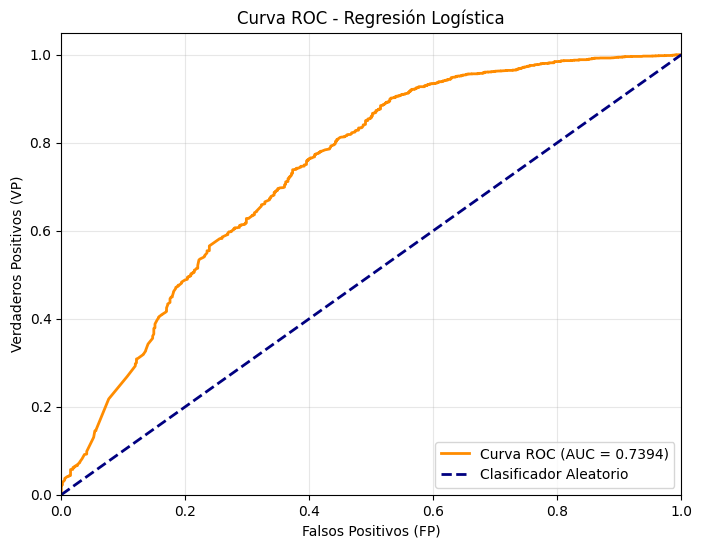

In [40]:
grafica_roc(pred_test_rf)

El valor de PR-AUC es: 0.9215


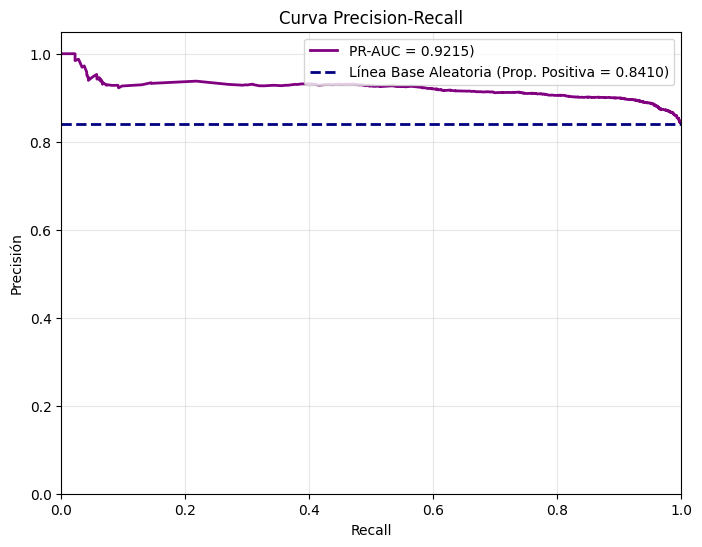

In [41]:
grafica_pr(pred_test_rf)

# No Supervisado - Kmeans Clustering

Se inicializa el modelo definiendo las variables que se usarán para agrupar (La columna features previamente definida) y se omite la variable de salida pero si se pone el número de clusters, en este caso 2, se recomienda o no el juego.

In [42]:
kmeans = KMeans(featuresCol='features',k=2)
k_model = kmeans.fit(train_df)

In [43]:
pred_test_k = k_model.transform(test_df)

In [44]:
wcss = k_model.summary.trainingCost
print(f"Inercia (WCSS): {wcss}")

evaluator = ClusteringEvaluator(predictionCol="prediction",
                                featuresCol="features",
                                metricName="silhouette",
                                distanceMeasure="squaredEuclidean")

silhouette_score = evaluator.evaluate(pred_test_k)
print(f"Coeficiente de Silueta: {silhouette_score}")

Inercia (WCSS): 1995.1784719836942
Coeficiente de Silueta: 0.8566044985685556


In [45]:
# Se ajustan algunos parámetros para tratar de mejorar el desempeño
kmeans2 = KMeans(featuresCol='features',k=2, initMode='random', initSteps=4, tol=0.001 )
k_model2 = kmeans2.fit(train_df)

In [46]:
pred_test_k2 = k_model2.transform(test_df)
wcss2 = k_model2.summary.trainingCost
print(f"Inercia (WCSS): {wcss2}")

evaluator = ClusteringEvaluator(predictionCol="prediction",
                                featuresCol="features",
                                metricName="silhouette",
                                distanceMeasure="squaredEuclidean")

silhouette_score2 = evaluator.evaluate(pred_test_k2)
print(f"Coeficiente de Silueta: {silhouette_score2}")

Inercia (WCSS): 1995.1784719836942
Coeficiente de Silueta: 0.8566044985685556


# PARTE 5 -  Análisis de resultados
---

#Supervisado: Regresión Logística

El primer modelo presenta muy buen accuracy y F1-score, a primera vista se pensaría que tienen buen desempeño. Sin embargo, al analizar la matriz de confusión, la curva ROC/AUC y la curva PR, se detecta que el modelo está prediciendo solo a la clase mayoritaria.

Como esta situación se trata de un sistema de recomendación se busca que también el modelo pueda predecir la clase minoritaría ("No se recomienda"), por lo que como seguna opción se aplica un balance de clases mediante la técnica de pesos y cambiando a un modelo Random Forest.

En este segundo modelo, el accuracy y el F1-score se mantienen relatavimente igual (bajan poco por debajo del 80%) pero se observa un comportamiento diferente en las demás métricas.

En la matriz de confusión ya hay mas verdaderamente negativos, es decir se están prediciendo correctamente más registros del tipo "No se recomienda". Pero esta mejora viene acompañada de una alza en los FN, lo cual es esperado en un problema de clases desbalanceadas.

En el caso de la curva ROC/AUC si se observa una mejora, acercándose el valor más hacia 1. Para la curva PR, el comportamiento es más constante pero sin mejorar siginificativamente la métrica.

Para efectos del ejercicio, el desempeño del segundo modelo es suficientemente bueno para lo que se espera en el sistema de recomendación tomando en cuenta el análisis inicial de las entregas anteriores, es decir, en general los jugaroes si recomiendan los juegos y son pocos los que no.

# No Supervisado - Kmeans Clustering

Como este problema se trata de un sistema de recomendación con solo dos clases, recomendendado o no (0 y 1), el uso de modelos No Supervisados no es tan útil como en otras situaciones, sin embargo se ofrece un modelo Kmeans como alternativa.

El primer modelo se entrena usando la columna de "features" previamente creada y definiendo el número de clusters en los cuales se quiere clasificar que por la naturaleza del problema son 2. La métrica de inercia resulta buena y el coeficiente de silueta cercano a uno indica que los clusters están bien agrupados y lejanos entre sí.

Como una segunda iteración se modifican algunos hiperparámetros del modelo como initMode, initSteps y tolerancia para ver si es posible obtener un mejor desempeño (No se varía el número de clusters por la naturaleza del problema, clasificar 2 clases). La realidad es que no, las métricas que se obtienen son muy similares entre sí.

Esto indica que los datos a entrenar ya tienen una cierta distribución y tendencia (Que tambien se confirmó con el modelo supervisado), por lo que intrinsecamente el modelo KMeans no puede ser mejorado.

Ambos resultados, tanto del modelo supervisado como no supervisado, confirman que la partición M y la distribución de los conjuntos de entrenamiento y prueba fue correcta y reflejan las características de la población P original (Cuya tendencia es que hay muchos más juegos recomendados que los que no).

Para mejorar el desempeño de los modelos habría que buscar un balance de las clases en los conjutos de entrenamiento y prueba pero eso introduciría un sesgo en los datos. Para efectos de este ejercicio, no se procederá con esa técnica de balanceo y se tomará como mejor modelo el Random Forest con balance de pesos.